<a href="https://colab.research.google.com/github/ssebastian0626/DSEM-assignment-4-/blob/Current-status-05.07.2026/04_weather_data_and_capacity_factor_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Downloading Historical Weather Data From ERA5 Dataset


In [ ]:
!pip install atlite
import atlite
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import rasterio
from atlite.gis import ExclusionContainer
import xarray as xr

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#CDS_API_KEY = "b6ec97b1-3bb0-4560-a287-f23fc0d54a14"
#with open('/root/.cdsapirc', 'w') as f:
#    f.write("url: https://cds.climate.copernicus.eu/api\n")
#    f.write(f"key: {CDS_API_KEY}\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
regions_path = "/content/drive/MyDrive/HW4/Data/PROCESSED/gadm_aut_level1.geojson"
regions = gpd.read_file(regions_path)

minx, miny, maxx, maxy = regions.total_bounds #AU border coordinates

buffer = 0.25 #0.25 degree buffer is added below
cutout = atlite.Cutout(
    path="/content/drive/MyDrive/HW4/Data/cutouts/AU-2019", #our target file to store downloads
    module="era5",
    x=slice(minx - buffer, maxx + buffer),
    y=slice(miny - buffer, maxy + buffer),
    time="2019")

/usr/local/lib/python3.12/dist-packages/atlite/cutout.py:156: UserWarning: Arguments module, x, y, time are ignored, since cutout is already built.
  warn(


In [ ]:
Path("/content/drive/MyDrive/HW4/Data/cutouts").mkdir(parents=True, exist_ok=True) #creates folder in drive
cutout.prepare(compression=None) #initiates connection to the CDS API

<Cutout "AU-2019">
 x = 9.50 ⟷ 17.25, dx = 0.25
 y = 46.25 ⟷ 49.25, dy = 0.25
 time = 2019-01-01 ⟷ 2019-12-31, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

Wind and Solar Capacity Factor Time Series per Modelled Region

In [ ]:
#The codes below are copied from the file named xxxxx

BASE = Path("/content/drive/MyDrive/HW4/Data")
RAW = BASE / "RAW"

gadm_path = RAW / "gadm" / "gadm_410-levels-ADM_1-AUT.gpkg"
gadm = gpd.read_file(gadm_path)
regions_m = gadm.to_crs("EPSG:3035").set_index("NAME_1")

#Protected Areas
landcover_path = (RAW / "copernicus-glc" / "PROBAV_LC100_global_v3.0.1_2019-nrt_Discrete-Classification-map_EPSG-4326-AT.tif")
suitable_land_codes = [20, 30, 40, 60]
wdpa_path = RAW / "wdpa" / "WDPA_Oct2022_Public_shp-AUT.tif"

#Solar Excluder
solar_excluder = ExclusionContainer(crs=3035, res=100)
solar_excluder.add_raster(wdpa_path,nodata=255) #protected areas
solar_excluder.add_raster(landcover_path,codes=suitable_land_codes,invert=True,nodata=255) #Cornelius suitable areas

#Wind Excluder
wind_excluder = ExclusionContainer(crs=3035, res=100)
wind_excluder.add_raster(wdpa_path,nodata=255) #protected areas
wind_excluder.add_raster(landcover_path,codes=suitable_land_codes,invert=True,nodata=255)#Cornelius suitable areas

airports_path = RAW / "ne_10m_airports.gpkg"
airports = gpd.read_file(airports_path)
airports_m = airports.to_crs("EPSG:3035")
airports_aut = gpd.sjoin(airports_m,regions_m[["geometry"]],how="inner",predicate="within") #Keep only airports inside Austria
wind_excluder.add_geometry(airports_aut.geometry,buffer=10_000) #airports buffer

roads_path = RAW / "ne_10m_roads.gpkg"
roads = gpd.read_file(roads_path)
roads_m = roads.to_crs("EPSG:3035")
roads_aut = gpd.sjoin(roads_m,regions_m[["geometry"]],how="inner",predicate="intersects")
wind_excluder.add_geometry(roads_aut.geometry,buffer=300)

wind_excluder.add_raster(landcover_path,codes=[50],buffer=1000,nodata=255)
elevation_path = RAW / "gebco" / "GEBCO_2014_2D-AT.nc"
wind_excluder.add_raster(elevation_path, codes=lambda x: x > 2000,crs=4326)

In [ ]:
A_solar = cutout.availabilitymatrix(regions_m, solar_excluder) #that is an availability matrix
A_wind = cutout.availabilitymatrix(regions_m, wind_excluder) #that is an availability matrix
#A_solar or A_wind shows that for each weather grid cell & region, what fraction of that cell's area is eligible for building solar panel&wind turbine

deployment_density = 3  #3 MW/km^2, given
area = cutout.grid.set_index(["y", "x"]).to_crs(3035).area / 1e6  #in km^2
area = xr.DataArray(area, dims=("spatial"))

capacity_matrix_solar = A_solar.stack(spatial=["y", "x"]) * area * deployment_density #potential capacity per grid cell in MW
capacity_matrix_wind = A_wind.stack(spatial=["y", "x"]) * area * deployment_density #potential capacity per grid cell in MW

In [ ]:
#Capacity Factor Time Series

wind_cf = cutout.wind(
    matrix=capacity_matrix_wind,
    turbine="Vestas_V112_3MW",
    index=regions_m.index,
    per_unit=True,
)

solar_cf = cutout.pv(
    matrix=capacity_matrix_solar,
    panel="CdTe",
    orientation="latitude_optimal",
    index=regions_m.index,
    per_unit=True,
)

#wind_cf
#solar_cf

/usr/local/lib/python3.12/dist-packages/atlite/convert.py:739: FutureWarning: aggregate_time='legacy' is deprecated and will be removed in a future release. Pass 'sum', 'mean', or None explicitly.
  return cutout.convert_and_aggregate(
/usr/local/lib/python3.12/dist-packages/atlite/convert.py:929: FutureWarning: aggregate_time='legacy' is deprecated and will be removed in a future release. Pass 'sum', 'mean', or None explicitly.
  return cutout.convert_and_aggregate(


In [ ]:
#Max Total Capacity for each region (in MW)
p_nom_max_wind = capacity_matrix_wind.sum("spatial").to_pandas()
p_nom_max_solar = capacity_matrix_solar.sum("spatial").to_pandas()
#p_nom_max_wind
#p_nom_max_solar

<Axes: title={'center': 'Solar PV Capacity Factor per Region'}, xlabel='time'>

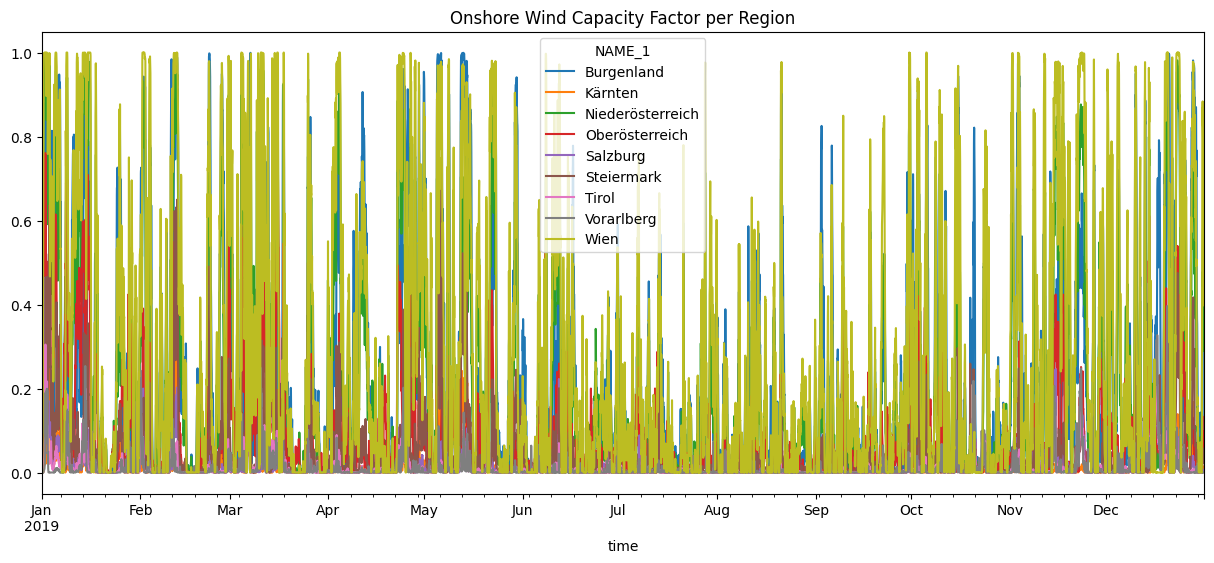

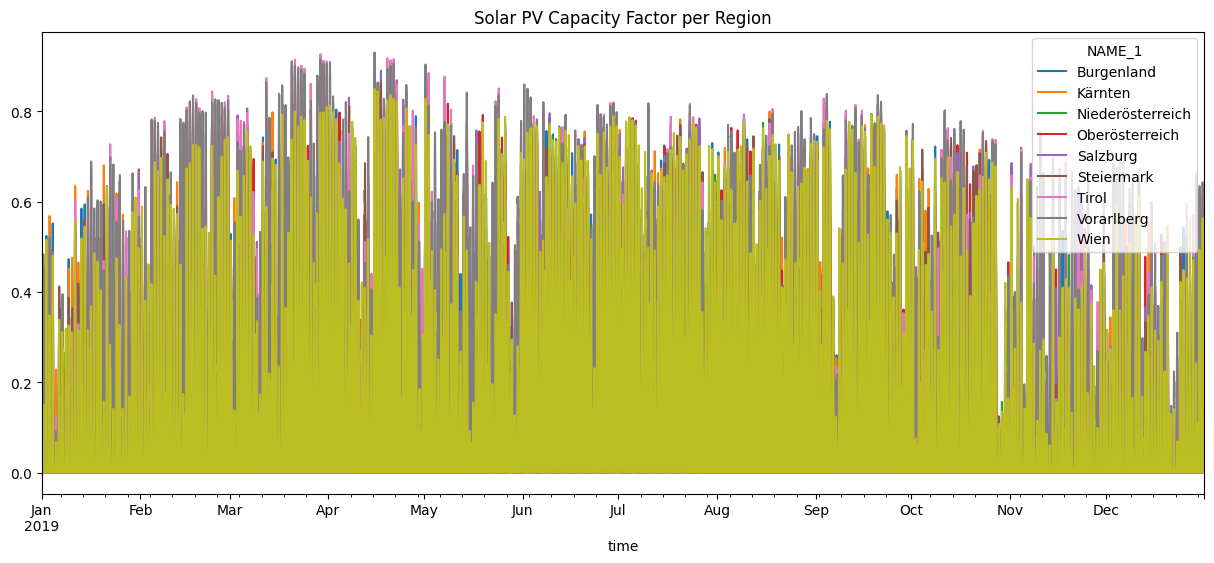

In [ ]:
#Plotting

wind_cf.to_pandas().plot(figsize=(15, 6), title="Onshore Wind Capacity Factor per Region")
solar_cf.to_pandas().plot(figsize=(15, 6), title="Solar PV Capacity Factor per Region")

In [ ]:
#We can save them to further use in PyPSA model

wind_cf.to_pandas().to_csv(BASE / "PROCESSED" / "wind_cf_regions.csv")
solar_cf.to_pandas().to_csv(BASE / "PROCESSED" / "solar_cf_regions.csv")
p_nom_max_wind.to_csv(BASE / "PROCESSED" / "p_nom_max_wind.csv")
p_nom_max_solar.to_csv(BASE / "PROCESSED" / "p_nom_max_solar.csv")